# 第 12 章 · 真实图片 Patch-GAN 代码实验

本页用真实花朵照片中的局部 patch 训练一个小型生成对抗网络。读者同时看损失曲线、真实 patch 和生成 patch。

[章节网页](../ch12.html)

## 运行内容

- 加载真实图片 patch
- 训练生成器和判别器
- 绘制生成 patch

## 0. 生成图片 patch

判别器学习区分真实 patch 和生成 patch，生成器学习骗过判别器。生成样本不追求完美，但应该呈现接近照片局部的颜色和纹理。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 安装并导入 GAN 需要的公开库。
gan_packages = {"torch": "torch>=2.2"}
missing = [package for module, package in gan_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import torch
from torch import nn

In [3]:
# 真实图片 Patch-GAN：用花朵照片中的 patch 训练生成器和判别器。
torch.manual_seed(7)
gan_photo = np.asarray(Image.fromarray(load_sample_image("flower.jpg")).resize((128, 128))).astype("float32") / 255.0
gan_patch_size = 16
gan_stride = 8
real_patch_list = []
for row in range(0, gan_photo.shape[0] - gan_patch_size + 1, gan_stride):
    for col in range(0, gan_photo.shape[1] - gan_patch_size + 1, gan_stride):
        real_patch_list.append(gan_photo[row:row + gan_patch_size, col:col + gan_patch_size])
real_patches_np = np.array(real_patch_list)
real_patches = torch.tensor(real_patches_np.reshape(len(real_patches_np), -1) * 2 - 1, dtype=torch.float32)

latent_dim = 24
patch_dim = real_patches.shape[1]
batch_size = 96

generator = nn.Sequential(
    nn.Linear(latent_dim, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, patch_dim),
    nn.Tanh(),
)
discriminator = nn.Sequential(
    nn.Linear(patch_dim, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 128),
    nn.LeakyReLU(0.2),
    nn.Linear(128, 1),
)
loss_fn = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(generator.parameters(), lr=0.0015, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.0015, betas=(0.5, 0.999))
gan_rows = []

for step in range(1, 401):
    idx = torch.randint(0, len(real_patches), (batch_size,))
    real_batch = real_patches[idx]
    z = torch.randn(batch_size, latent_dim)
    fake_batch = generator(z).detach()

    real_logits = discriminator(real_batch)
    fake_logits = discriminator(fake_batch)
    d_loss = loss_fn(real_logits, torch.ones_like(real_logits)) + loss_fn(fake_logits, torch.zeros_like(fake_logits))
    opt_d.zero_grad()
    d_loss.backward()
    opt_d.step()

    z = torch.randn(batch_size, latent_dim)
    generated = generator(z)
    g_logits = discriminator(generated)
    g_loss = loss_fn(g_logits, torch.ones_like(g_logits))
    opt_g.zero_grad()
    g_loss.backward()
    opt_g.step()

    if step % 50 == 0:
        with torch.no_grad():
            gan_rows.append({
                "训练步": step,
                "判别器损失": float(d_loss),
                "生成器损失": float(g_loss),
                "真实样本评分": float(torch.sigmoid(discriminator(real_batch)).mean()),
                "生成样本评分": float(torch.sigmoid(discriminator(generator(torch.randn(batch_size, latent_dim)))).mean()),
            })

with torch.no_grad():
    gan_samples = generator(torch.randn(16, latent_dim)).reshape(16, gan_patch_size, gan_patch_size, 3).numpy()
gan_trace = pd.DataFrame(gan_rows)
display(pd.DataFrame({
    "真实图片": ["flower.jpg"],
    "patch 数": [len(real_patches)],
    "patch 尺寸": [f"{gan_patch_size}x{gan_patch_size}"],
    "生成向量维度": [patch_dim],
}))
display(gan_trace.round(3))

,真实图片,patch 数,patch 尺寸,生成向量维度
0,flower.jpg,225,16x16,768


,训练步,判别器损失,生成器损失,真实样本评分,生成样本评分
0,50,1.914,0.281,0.996,0.848
1,100,1.529,1.456,0.619,0.392
2,150,0.854,1.255,0.765,0.480
3,200,1.089,1.079,0.607,0.365
4,250,1.242,0.906,0.585,0.465
5,300,1.115,1.005,0.662,0.408
6,350,1.000,1.112,0.658,0.362
7,400,1.017,0.979,0.669,0.413


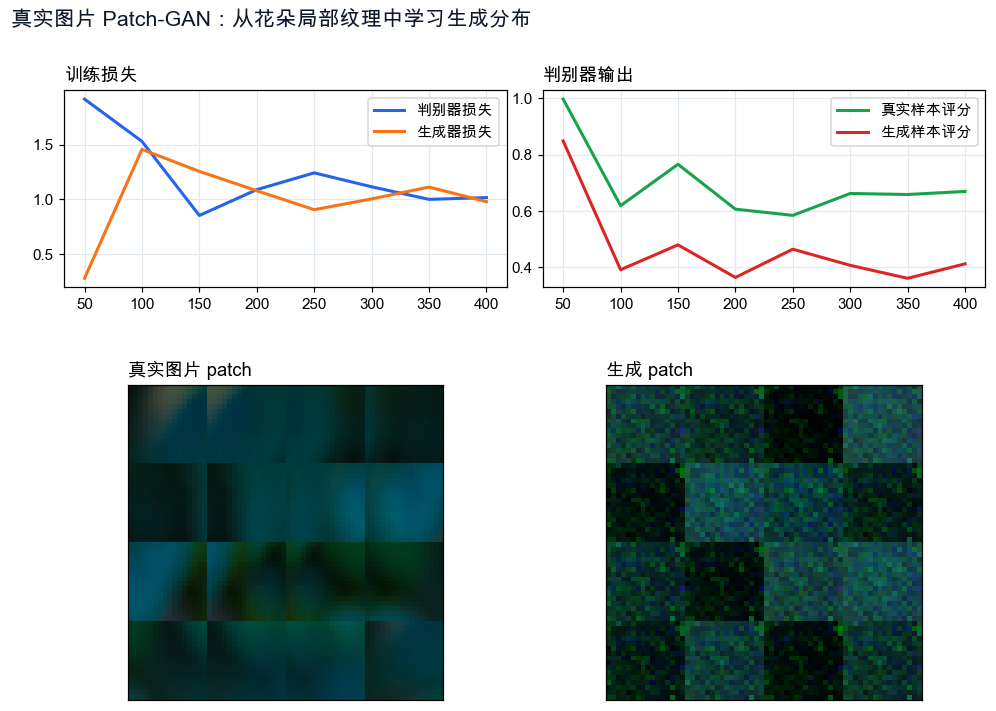

In [4]:
# 绘制训练曲线、真实 patch 和生成 patch。
fig = plt.figure(figsize=(10.8, 7.2))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.6], hspace=0.38, wspace=0.18)
ax_loss = fig.add_subplot(gs[0, :2])
ax_score = fig.add_subplot(gs[0, 2:])
ax_loss.plot(gan_trace["训练步"], gan_trace["判别器损失"], color="#2563eb", linewidth=2.0, label="判别器损失")
ax_loss.plot(gan_trace["训练步"], gan_trace["生成器损失"], color="#f97316", linewidth=2.0, label="生成器损失")
ax_loss.set_title("训练损失", loc="left", fontweight="bold")
ax_loss.grid(True, color="#e2e8f0", linewidth=0.8)
ax_loss.legend()

ax_score.plot(gan_trace["训练步"], gan_trace["真实样本评分"], color="#16a34a", linewidth=2.0, label="真实样本评分")
ax_score.plot(gan_trace["训练步"], gan_trace["生成样本评分"], color="#dc2626", linewidth=2.0, label="生成样本评分")
ax_score.set_title("判别器输出", loc="left", fontweight="bold")
ax_score.grid(True, color="#e2e8f0", linewidth=0.8)
ax_score.legend()

def patch_tile(images, grid=4):
    rows = [
        np.concatenate([images[i * grid + j] for j in range(grid)], axis=1)
        for i in range(grid)
    ]
    return np.concatenate(rows, axis=0)


real_tile = patch_tile(real_patches_np[:16])
fake_tile = patch_tile(((gan_samples[:16] + 1) / 2).clip(0, 1))
ax_real = fig.add_subplot(gs[1, :2])
ax_fake = fig.add_subplot(gs[1, 2:])
ax_real.imshow(real_tile)
ax_real.set_title("真实图片 patch", loc="left", fontweight="bold")
ax_fake.imshow(fake_tile)
ax_fake.set_title("生成 patch", loc="left", fontweight="bold")
for ax in (ax_real, ax_fake):
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("真实图片 Patch-GAN：从花朵局部纹理中学习生成分布", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()